# 🚗 Used Car Price Prediction in Egypt

## Objective

The objective of this project is to build a machine learning model capable of predicting the selling price of used cars listed in *Egypt* based on vehicle characteristics such as **make, model, year, mileage, transmission, and other available features.**

The project follows a complete end-to-end machine learning workflow, covering every stage of a typical machine learning project, including:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Selection and Comparison
- Hyperparameter Optimization
- Learning Curve Analysis
- Model Evaluation
- Model Interpretation (Permutation Feature Importance)
- Residual and Error Analysis
- Model Serialization

The final model is trained using Scikit-learn pipelines, allowing raw vehicle information to be transformed automatically into accurate price predictions.


## 1. Import Libraries

This section imports all libraries required for data **manipulation,
visualization, preprocessing, model training, and evaluation**.

In [39]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import loguniform, randint, uniform

from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
    make_column_selector,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.model_selection import (
    train_test_split,
    KFold,
    RandomizedSearchCV,
    cross_validate
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve

from category_encoders import TargetEncoder

from src.feature_engineering import CarUsedFeatureEngineer

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor



sns.set_theme(style="whitegrid", palette="viridis")

## 2. Load Dataset

Load the scraped *Hatla2ee* used cars dataset and inspect its structure before
performing any preprocessing.

In [40]:
df = pd.read_csv(PROJECT_ROOT / "data" / "hatla2ee_scraped_data.csv")

## 3. Dataset Overview

Perform an initial exploration to understand the **size** of the dataset,
**data types**, **unique values**, and **general characteristics.**

In [41]:
df.shape

(33559, 13)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33559 entries, 0 to 33558
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Name                    33559 non-null  str  
 1   Price                   32625 non-null  str  
 2   Color                   33559 non-null  str  
 3   Mileage                 31440 non-null  str  
 4   Make                    33559 non-null  str  
 5   Model                   33559 non-null  str  
 6   City                    33559 non-null  str  
 7   Date Displayed          33559 non-null  str  
 8   Automatic Transmission  33559 non-null  str  
 9   Air Conditioner         33559 non-null  str  
 10  Power Steering          33559 non-null  str  
 11  Remote Control          33559 non-null  str  
 12  Item URL                33559 non-null  str  
dtypes: str(13)
memory usage: 7.7 MB


In [43]:
df.sample(5)

,Name,Price,Color,Mileage,Make,Model,City,Date Displayed,Automatic Transmission,Air Conditioner,Power Steering,Remote Control,Item URL
28074,Brilliance FRV 2009,NaN,Silver,NaN,Brilliance,FRV,Marsa Matrouh,2024-02-16,No,Yes,No,Yes,https://eg.hatla2ee.com/en/car/brilliance/frv/...
9201,Hyundai Tucson 2023,"1,950,000 EGP",White,25 Km,Hyundai,Tucson,Mansoura,2023-12-23,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/hyundai/tucson/...
24502,Kia Spectra 2002,"330,000 EGP",Gray,"253,000 Km",Kia,Spectra,Al Shorouk,2024-02-16,Yes,No,No,No,https://eg.hatla2ee.com/en/car/kia/spectra/628...
10082,Mercedes GLC 200 2024,"5,350,000 EGP",Dark blue,NaN,Mercedes,GLC 200,Madinaty,2023-12-16,No,No,No,No,https://eg.hatla2ee.com/en/car/mercedes/GLC-20...
16273,Nissan Sentra 2018,"655,000 EGP",Beige,"110,000 Km",Nissan,Sentra,Borg el arab,2023-10-17,Yes,Yes,Yes,Yes,https://eg.hatla2ee.com/en/car/nissan/sentra/6...


In [44]:
df.nunique()

Name                       4158
Price                       828
Color                        24
Mileage                    1084
Make                        101
Model                       889
City                        103
Date Displayed              124
Automatic Transmission        2
Air Conditioner               2
Power Steering                2
Remote Control                2
Item URL                  22048
dtype: int64

## 4. Data Quality Assessment

Identify **missing values, duplicated records, inconsistent formats,**
and potential data quality issues that require cleaning.

In [45]:
missing_data = (
    pd.concat(
        [df.isna().sum(), df.isna().mean().mul(100)],
        axis=1,
        keys=["total_missing", "percent"]
    )
    .query("total_missing > 0")
    .sort_values(by="percent", ascending=False)
)

missing_data

,total_missing,percent
Mileage,2119,6.314253
Price,934,2.783158


In [46]:
df.duplicated().sum()

np.int64(11507)

## 5. Data Cleaning


Clean the dataset by **removing duplicates**, **handling missing values**,
**converting data types**, and **extracting useful information** from existing features.

In [47]:
df.drop_duplicates(inplace=True)

In [48]:
df['Year'] = df['Name'].str.extract(r'(\d{4})$').astype('Int64')

In [49]:
df.dropna(subset='Price', inplace=True)

df["Price"] = df["Price"].str.replace('EGP', '').str.replace(',', '').astype(float)

In [50]:
df['Mileage'] = pd.to_numeric(df['Mileage'].str.replace('Km','').str.replace(',', ''), errors="coerce").astype('Int64')

In [51]:
df['Date Displayed'] = pd.to_datetime(df['Date Displayed'])

## 6. Statistical Summary


Review descriptive statistics of numerical features to understand
their distributions and identify potential outliers.

In [52]:
df.describe()

,Price,Mileage,Date Displayed,Year
count,2.198100e+04,20787.0,21981,21980.0
mean,8.477219e+05,135029.740703,2023-12-25 01:50:07.451890,2013.345496
min,1.060000e+03,0.0,2023-10-16 00:00:00,1963.0
25%,3.600000e+05,70000.0,2023-11-23 00:00:00,2009.0
50%,6.150000e+05,127000.0,2023-12-28 00:00:00,2015.0
75%,9.500000e+05,190000.0,2024-01-30 00:00:00,2020.0
max,2.000000e+07,2226000.0,2024-02-16 00:00:00,2024.0
std,9.321061e+05,87770.640224,NaN,8.802235


## 7. Exploratory Data Analysis

Explore relationships between variables using visualizations to identify
patterns, trends, and factors affecting car prices.

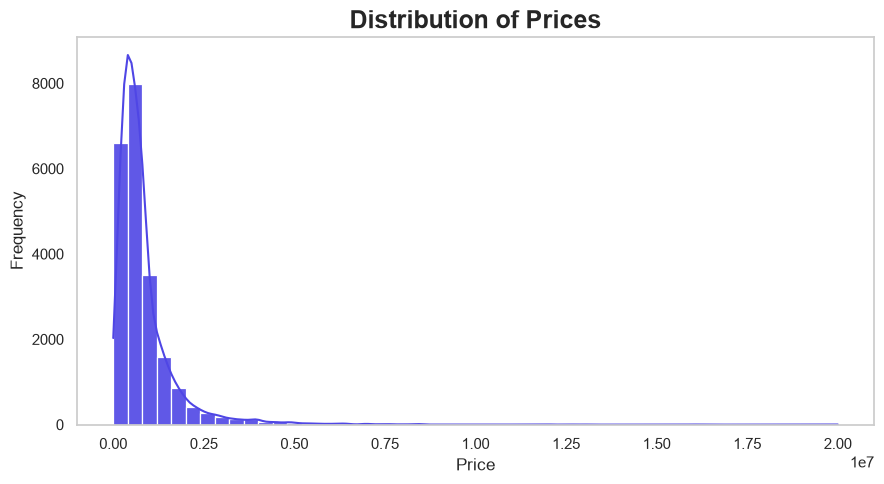

In [53]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Price",
    bins=50,
    kde=True,
    color="#4F46E5",
    edgecolor="white",
    linewidth=0.9,
    alpha=0.9
)

plt.title("Distribution of Prices", fontsize=18, weight="bold")
plt.xlabel("Price", fontsize=12.5)
plt.ylabel("Frequency", fontsize=12.5)
plt.grid(visible=False)

plt.tight_layout()

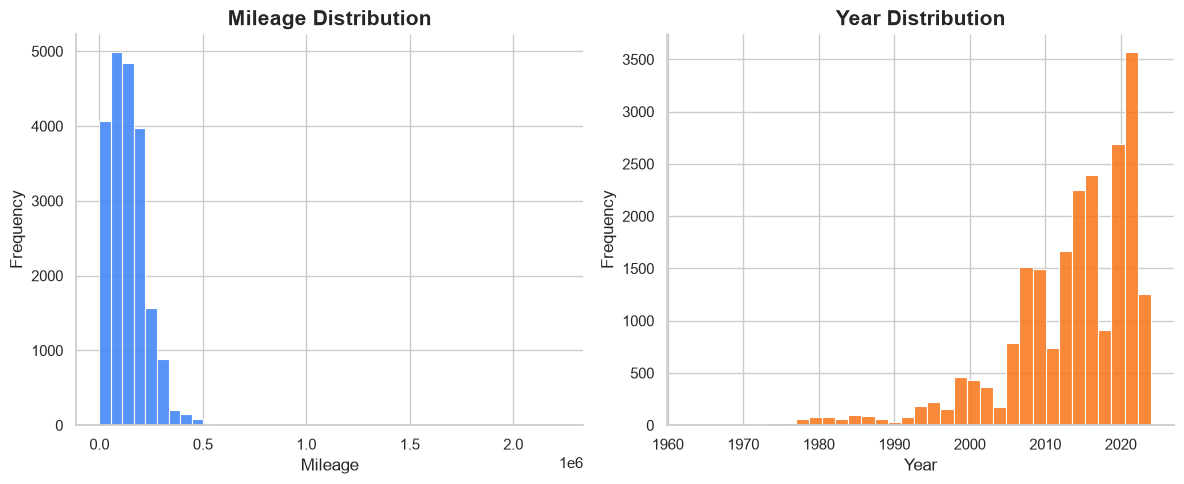

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    df["Mileage"],
    bins=40,
    color="#3B82F6",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.85,
    ax=axes[0]
)
axes[0].set_title("Mileage Distribution", fontsize=15, weight="bold")
axes[0].set_xlabel("Mileage")
axes[0].set_ylabel("Frequency")

sns.histplot(
    df["Year"],
    bins=35,
    color="#F97316",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.85,
    ax=axes[1]
)
axes[1].set_title("Year Distribution", fontsize=15, weight="bold")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Frequency")

sns.despine()
plt.tight_layout()

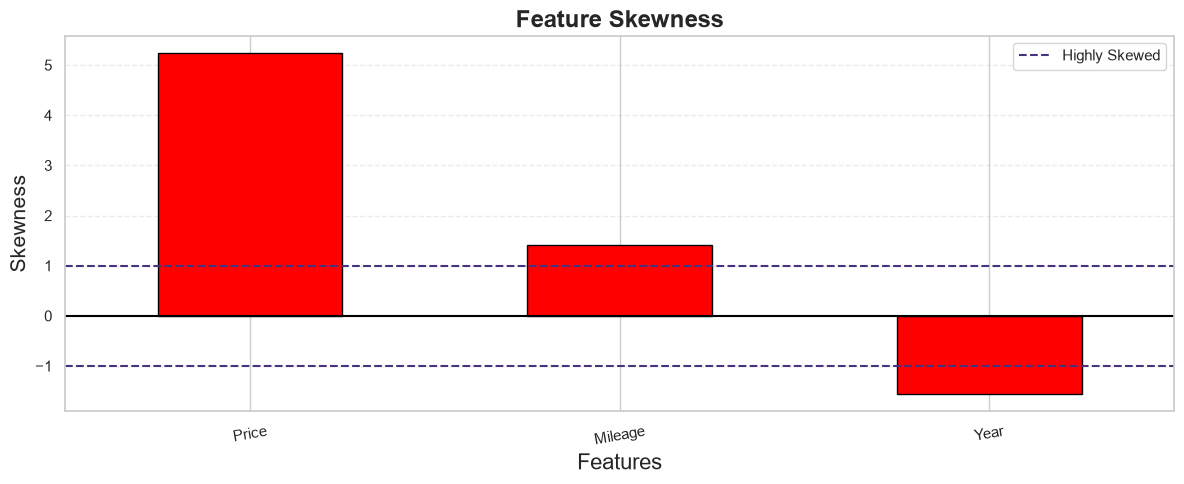

In [55]:
skewness = df.select_dtypes(np.number).skew()

plt.figure(figsize=(12, 5))

ax = skewness.plot(
    kind='bar',
    color='red',
    edgecolor='black'
)

plt.title('Feature Skewness', fontsize=17, weight="bold")
plt.ylabel('Skewness', fontsize=15)
plt.xlabel('Features', fontsize=16)
plt.xticks(rotation=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.axhline(0, color='black')
plt.axhline(1, linestyle='--', label='Highly Skewed')
plt.axhline(-1, linestyle='--')

plt.legend()
plt.tight_layout()

C:\Users\Marwan\AppData\Local\Temp\ipykernel_788\318548393.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


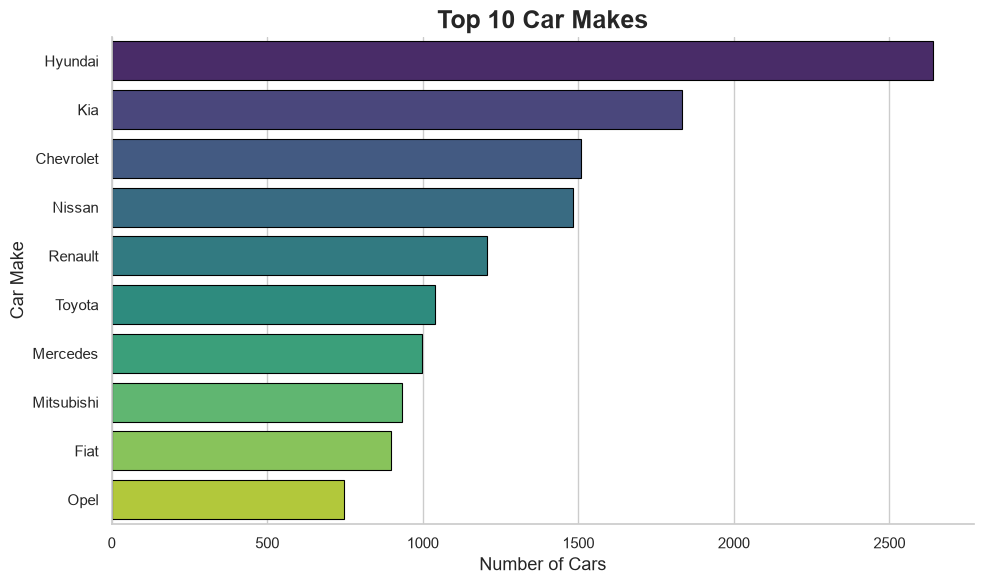

In [56]:
counts = df['Make'].value_counts().nlargest(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=counts.values,
    y=counts.index,
    palette="viridis",
    edgecolor="black",
    linewidth=0.8
)

plt.title("Top 10 Car Makes", fontsize=18, weight="bold")
plt.xlabel("Number of Cars", fontsize=13)
plt.ylabel("Car Make", fontsize=13)

sns.despine()
plt.tight_layout()

C:\Users\Marwan\AppData\Local\Temp\ipykernel_788\3162151035.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


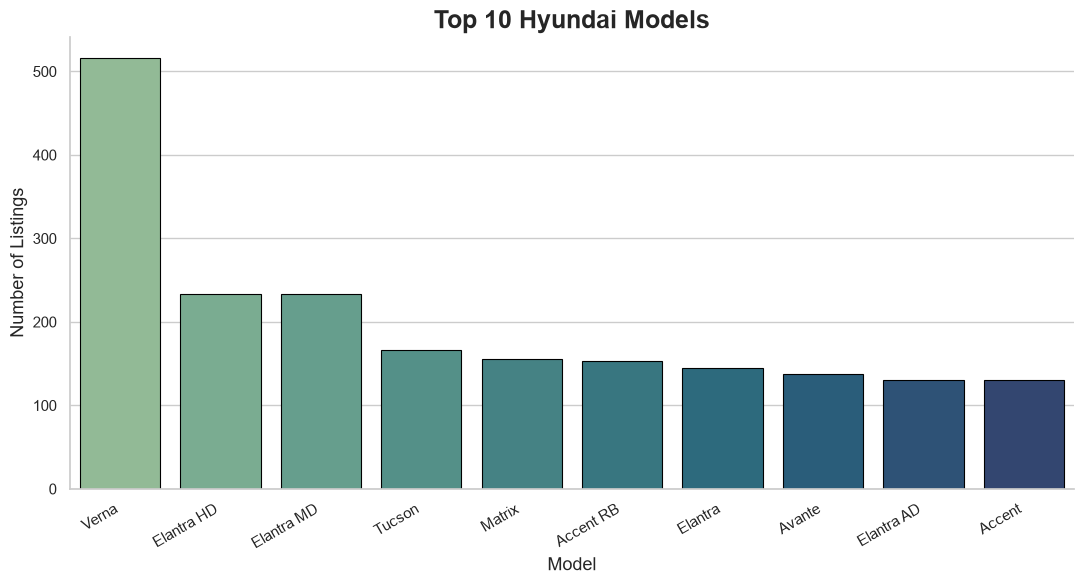

In [57]:
most_frequent_make = df["Make"].mode()[0]

top_models = (
    df.query("Make == @most_frequent_make")["Model"]
      .value_counts()
      .head(10)
      .reset_index()
)


plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=top_models,
    x=top_models["Model"],
    y=top_models["count"],
    palette="crest",
    edgecolor="black",
    linewidth=0.8
)


plt.title(f"Top 10 {most_frequent_make} Models", fontsize=18, fontweight="bold")
plt.xlabel("Model", fontsize=13)
plt.ylabel("Number of Listings", fontsize=13)

plt.xticks(rotation=30, ha="right")


sns.despine()
plt.tight_layout()

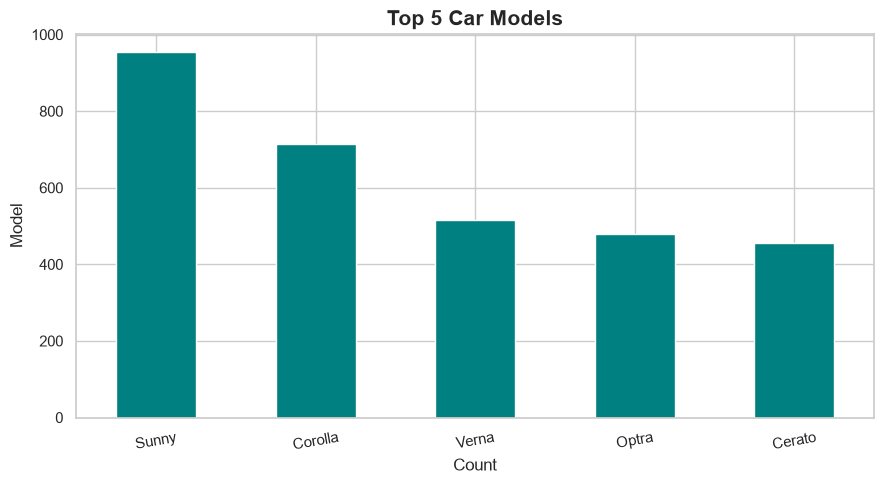

In [58]:
df["Model"].value_counts().head(5).plot(
    kind="bar",
    color="teal",
    figsize=(9, 5)
)

plt.title("Top 5 Car Models", fontsize=15, fontweight="bold")
plt.xlabel("Count", fontsize=12)
plt.ylabel("Model", fontsize=12)

plt.xticks(rotation=10)

plt.tight_layout()

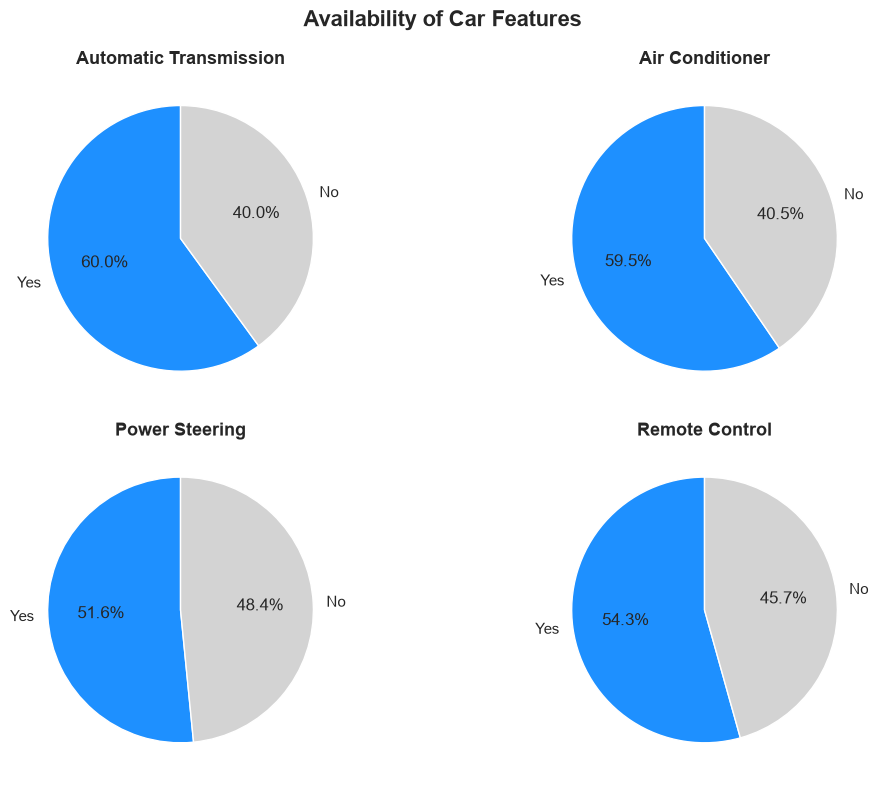

In [59]:
cols = [
    "Automatic Transmission",
    "Air Conditioner",
    "Power Steering",
    "Remote Control"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), cols):
    df[col].value_counts().plot(
        kind="pie",
        colors=["dodgerblue", "lightgray"],
        autopct="%1.1f%%",
        startangle=90,
        ax=ax,
        ylabel=""
    )

    ax.set_title(col, fontsize=13, fontweight="bold")

plt.suptitle("Availability of Car Features", fontsize=16, fontweight="bold")
plt.tight_layout()

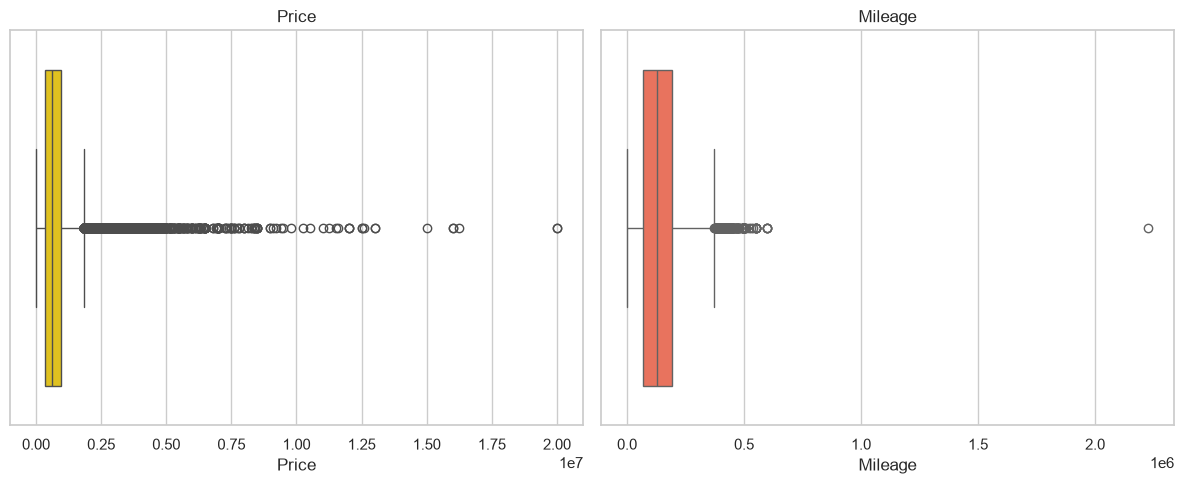

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=df["Price"], ax=axes[0], color="gold")
axes[0].set_title("Price")

sns.boxplot(x=df["Mileage"], ax=axes[1], color="tomato")
axes[1].set_title("Mileage")

plt.tight_layout()

In [61]:
df["Price"] = df["Price"].clip(
    upper=df["Price"].quantile(0.99),
    lower=df["Price"].quantile(0.05)
    )

df["Mileage"] = df["Mileage"].clip(upper=df["Mileage"].quantile(0.99))

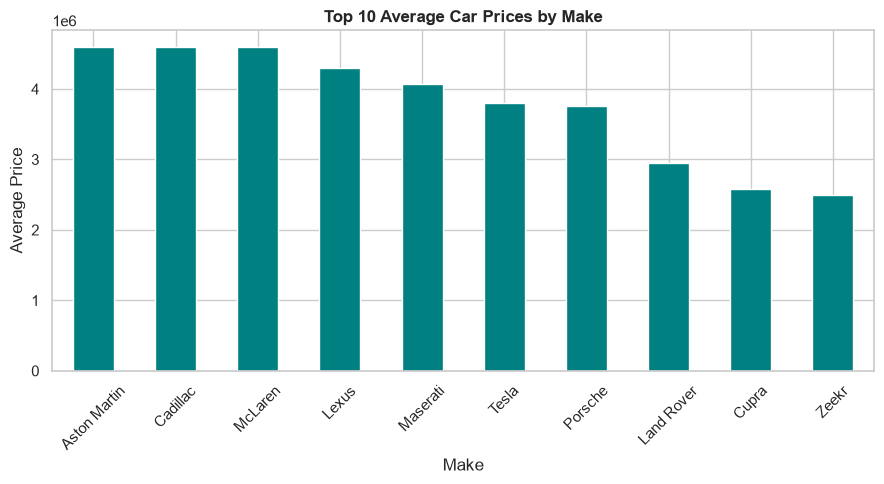

In [62]:
df.groupby("Make")["Price"].mean().nlargest(10).plot(
    kind="bar",
    color="teal",
    figsize=(9, 5)
)

plt.title("Top 10 Average Car Prices by Make", weight="bold")
plt.xlabel("Make")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.tight_layout()

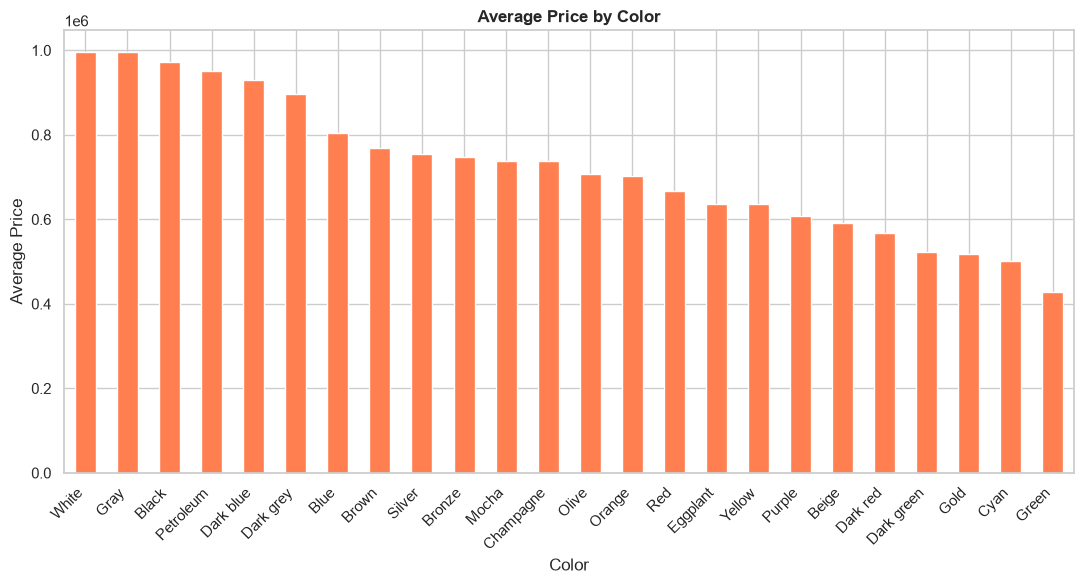

In [63]:
df.groupby("Color")["Price"].mean().sort_values(ascending=False).plot(
    kind="bar",
    color="coral",
    figsize=(11, 6)
)

plt.title("Average Price by Color", weight="bold")
plt.xlabel("Color")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

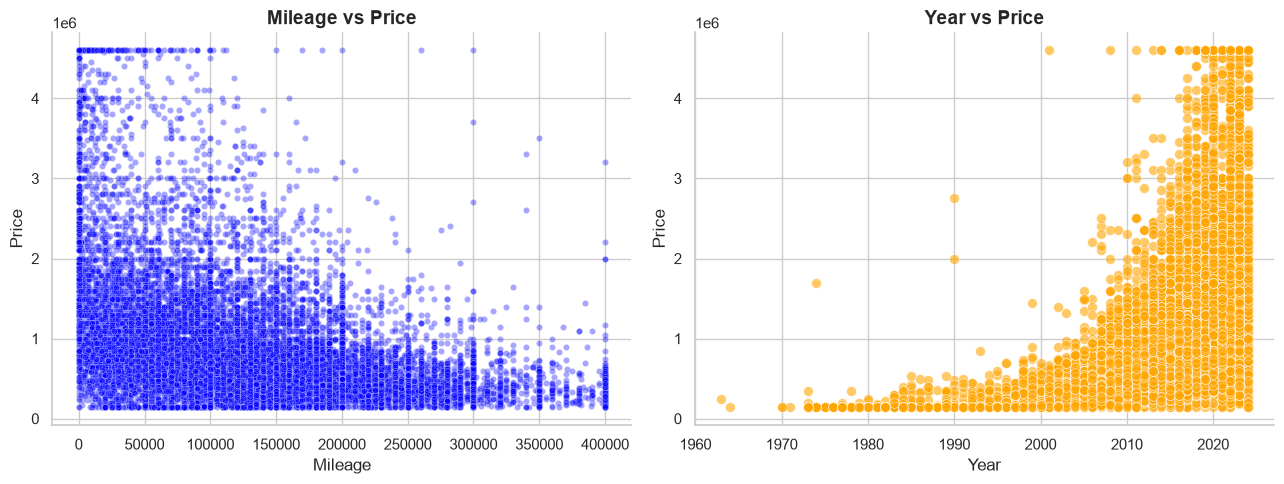

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=df,
    x="Mileage",
    y="Price",
    color="blue",
    alpha=0.35,
    s=20,
    ax=axes[0]
)
axes[0].set_title("Mileage vs Price", fontsize=14, fontweight="bold")

sns.scatterplot(
    data=df,
    x="Year",
    y="Price",
    color="orange",
    alpha=0.6,
    s=50,
    ax=axes[1]
)
axes[1].set_title("Year vs Price", fontsize=14, fontweight="bold")

sns.despine()
plt.tight_layout()

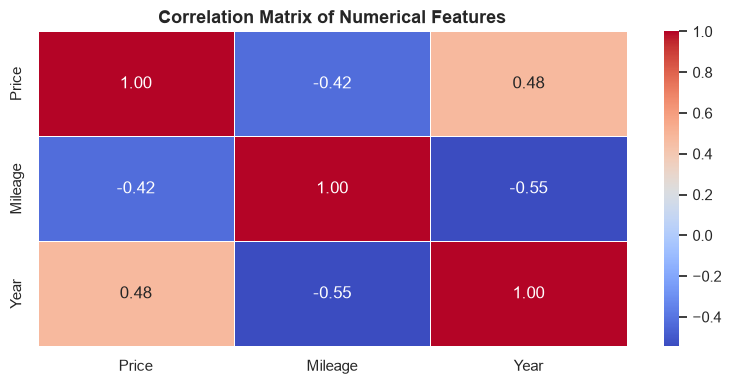

In [65]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 4))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.6
)

plt.title('Correlation Matrix of Numerical Features', fontsize=13, fontweight="bold")

plt.tight_layout()

## 8. Train-Test Split

Split the dataset into training and testing sets to evaluate model performance on unseen data and prevent information leakage.

In [66]:
df.drop(columns=['Name', 'City', 'Item URL'], inplace=True)

In [67]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Price', axis=1),
                                                    df['Price'],
                                                    test_size=0.25,
                                                    random_state=42)

## 9. Data Preprocessing

Build preprocessing pipelines for numerical and categorical variables, including scaling, encoding, and missing value handling.

In [68]:
target_cat_cols = ['Make', 'Model']

one_hot_cat_cols = ['Color']

binary_cat_cols = [
    "Automatic Transmission",
    "Air Conditioner",
    "Power Steering",
    "Remote Control"
]

In [69]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

target_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    TargetEncoder(),
    StandardScaler()
)

one_hot_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

ordinal_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder(categories=[["No", "Yes"]] * len(binary_cat_cols))
)

In [70]:
preprocessing = ColumnTransformer([
    ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
    ("target", target_pipeline, target_cat_cols),
    ("onehot", one_hot_pipeline, one_hot_cat_cols),
    ("binary", ordinal_pipeline, binary_cat_cols),
], remainder=one_hot_pipeline)

## 10. Model Training

Train multiple regression models using cross-validation and compare their predictive performance.

In [71]:
models = {
    "Linear Regression":
        TransformedTargetRegressor(
            regressor=LinearRegression(),
            func=np.log1p,
            inverse_func=np.expm1
        ),

    "SVR":
        TransformedTargetRegressor(
            regressor=SVR(max_iter=5000),
            func=np.log1p,
            inverse_func=np.expm1
        ),

    "Random Forest":
        RandomForestRegressor(random_state=42, n_jobs=-1),

    "ExtraTrees": ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        n_jobs=-1,
    ),

    "XGBoost":
        XGBRegressor(random_state=42, n_jobs=-1)

}

In [72]:
def evaluate_model(model, X_train, y_train):

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_validate(
        Pipeline([
          ("feature_engineering", CarUsedFeatureEngineer()),
          ("preprocessing", preprocessing),
          ("model", model)
        ]),
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        return_train_score=True,
        n_jobs=-1
    )

    return {
        "Train R2": scores["train_score"].mean(),
        "Validation R2": scores["test_score"].mean(),
        "Validation R2 Std": scores["test_score"].std()
      }

In [73]:
results = {}

for name, model in models.items():
    results[name] = evaluate_model(model, X_train, y_train)

results_df = pd.DataFrame(results).T.sort_values("Validation R2", ascending=False).round(4)

print(results_df)

                   Train R2  Validation R2  Validation R2 Std
LightGBM             0.9314         0.8548             0.0058
XGBoost              0.9749         0.8517             0.0064
ExtraTrees           1.0000         0.8482             0.0103
Random Forest        0.9830         0.8462             0.0063
SVR                  0.8722         0.8203             0.0090
Linear Regression    0.6992         0.6857             0.0226


## 11. Hyperparameter Tuning

Optimize the best-performing models using RandomizedSearchCV
to improve generalization performance.

In [74]:
cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

param_distributions = {
    "model__n_estimators": randint(200, 800),
    "model__learning_rate": loguniform(0.02, 0.15),

    "model__max_depth": randint(4, 8),
    "model__num_leaves": randint(20, 100),

    "model__min_child_samples": randint(10, 60),

    "model__subsample": uniform(0.7, 0.3),
    "model__colsample_bytree": uniform(0.7, 0.3),

    "model__reg_alpha": loguniform(1e-5, 1),
    "model__reg_lambda": loguniform(1e-5, 10)
}

lgbm = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    force_col_wise=True
)

pipeline = Pipeline([
    ("feature_engineering", CarUsedFeatureEngineer()),
    ("preprocessing", preprocessing),
    ("model", lgbm)
])

random_search_lb = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=100,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    random_state=42,
)

In [75]:
random_search_lb.fit(X_train, y_train)

print("Best Params:", random_search_lb.best_params_, '\n')
print("Best CV R²:", round(random_search_lb.best_score_, 4))

Best Params: {'model__colsample_bytree': np.float64(0.7110049608671793), 'model__learning_rate': np.float64(0.033260424448350236), 'model__max_depth': 6, 'model__min_child_samples': 12, 'model__n_estimators': 562, 'model__num_leaves': 37, 'model__reg_alpha': np.float64(0.0017260836313776789), 'model__reg_lambda': np.float64(0.015692914144126387), 'model__subsample': np.float64(0.7727411510904189)} 

Best CV R²: 0.8601


In [76]:
param_distributions = {
    "model__n_estimators": randint(200, 1000),
    "model__max_depth": randint(4, 12),
    "model__learning_rate": loguniform(0.005, 0.1),
    "model__min_child_weight": randint(1, 15),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__gamma": uniform(0, 5),
    "model__reg_alpha": loguniform(1e-8, 10),
    "model__reg_lambda": loguniform(1e-8, 10)
}

xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("feature_engineering", CarUsedFeatureEngineer()),
    ("preprocessing", preprocessing),
    ("model", xgb)
])

random_search_xg = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=150,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    random_state=42,
)

In [77]:
random_search_xg.fit(X_train, y_train)

print("Best params:", random_search_xg.best_params_,'\n')
print("Best CV R²:", round(random_search_xg.best_score_, 4))

Best params: {'model__colsample_bytree': np.float64(0.6491107558650834), 'model__gamma': np.float64(4.382220379376469), 'model__learning_rate': np.float64(0.03431116367686493), 'model__max_depth': 5, 'model__min_child_weight': 2, 'model__n_estimators': 908, 'model__reg_alpha': np.float64(1.1922193473338838e-05), 'model__reg_lambda': np.float64(2.161777044706983e-06), 'model__subsample': np.float64(0.7518769632669068)} 

Best CV R²: 0.8652


In [78]:
best_model_Xg = random_search_xg.best_estimator_

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model_Xg,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

### Interpretation

The learning curve shows that the training score decreases slightly while the cross-validation score steadily improves as the number of training examples increases. This behavior indicates that the model benefits from additional training data and is learning meaningful relationships rather than memorizing the training set.


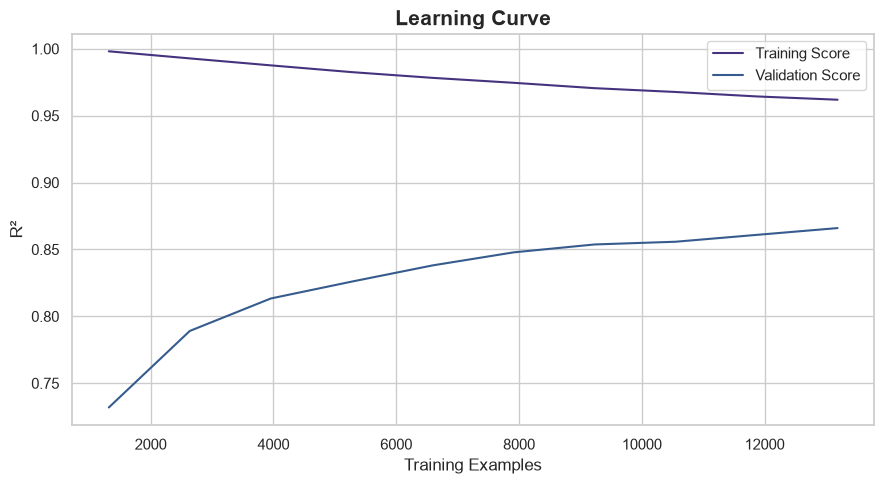

In [79]:
plt.figure(figsize=(9,5))

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Examples")
plt.ylabel("R²")
plt.title("Learning Curve", fontsize=15, weight='bold')
plt.legend(loc='best')
plt.grid(True)

plt.tight_layout()

## 12. Final Model Evaluation

Evaluate the tuned model on the test set using regression metrics and summarize the final performance.

In [80]:
best_model_Xg.fit(X_train, y_train)

y_pred = best_model_Xg.predict(X_test)

print(f'MAE : {round(mean_absolute_error(y_test, y_pred), 0)}')
print(f'RMSE : {round(np.sqrt(mean_squared_error(y_test, y_pred)), 0)}')
print(f'R² : {round(r2_score(y_test, y_pred), 4)}')

MAE : 124506.0
RMSE : 246130.0
R² : 0.8962


## 13. Permutation Feature Importance

To improve the interpretability of the final XGBoost model, **Permutation Feature Importance** was computed. This technique measures the decrease in model performance when the values of a feature are randomly shuffled, indicating how much the model relies on that feature. **The analysis is presented for model interpretation only and was not used for further model optimization.**

In [81]:
result = permutation_importance(
    estimator=best_model_Xg,
    X=X_test,
    y=y_test,
    scoring="r2",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)


In [82]:
feature_importance = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": result.importances_mean
    }).sort_values("Importance")
)

**Note:**  Permutation importance was used for interpretation, not feature selection.

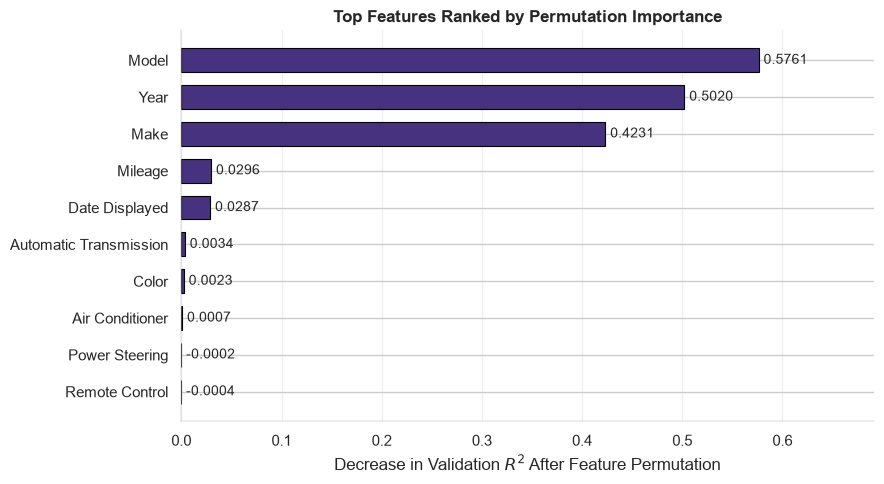

In [83]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    height=0.65,
    edgecolor="black",
    linewidth=0.8
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{width:.4f}",
        va="center",
        ha="left",
        fontsize=10
    )

plt.title("Top Features Ranked by Permutation Importance", weight='bold')
plt.xlabel("Decrease in Validation $R^2$ After Feature Permutation")

plt.grid(axis="x", alpha=0.3)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.4)
ax.spines["bottom"].set_alpha(0.4)

ax.set_xlim(0, feature_importance["Importance"].max() * 1.2)

plt.tight_layout()

## 14. Error Analysis

Analyze the model's prediction errors using residuals and the largest prediction errors. **This analysis helps identify potential bias, noisy target values, outliers, and difficult cases that contribute to the overall prediction error.**

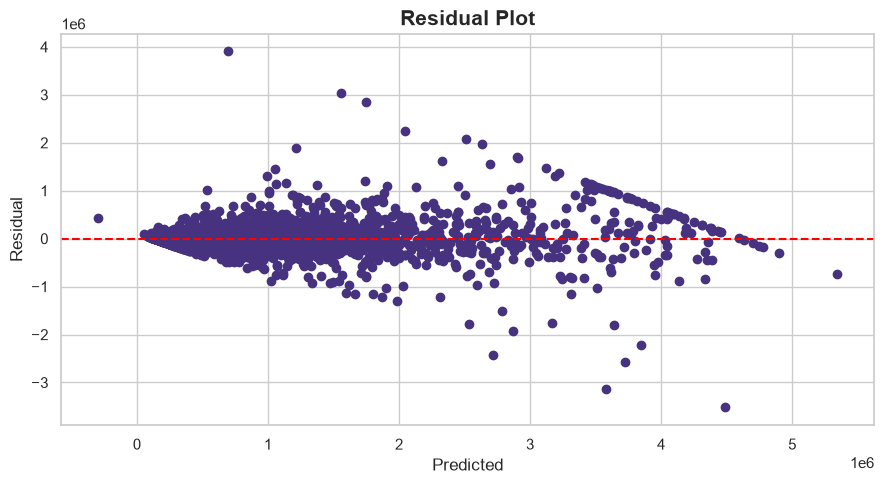

In [84]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))

plt.scatter(y_pred, residuals)

plt.title("Residual Plot", fontsize=15, weight='bold')
plt.xlabel("Predicted")
plt.ylabel("Residual")

plt.axhline(0, color='red', linestyle='--')

plt.tight_layout()

### Investigating the Largest Prediction Errors

By inspecting the worst predictions, we can determine whether these large errors are caused by **unusual observations, missing information, or inherent noise in the target variable** rather than shortcomings of the machine learning model itself.

In [85]:
errors = np.abs(y_test - y_pred)

worst_indices_pos = np.argsort(errors.values)[-5:]

for i in worst_indices_pos:
    print("Index:", i)
    print("Actual:", y_test.iloc[i])
    print("Predicted:", y_pred[i])
    print(X_test.iloc[i])
    print("-"*50)

Index: 1081
Actual: 4600000.0
Predicted: 1.7501789e+06
Color                                   Black
Mileage                                 80000
Make                                     Audi
Model                                      Q8
Date Displayed            2024-01-08 00:00:00
Automatic Transmission                    Yes
Air Conditioner                           Yes
Power Steering                            Yes
Remote Control                            Yes
Year                                     2021
Name: 7539, dtype: object
--------------------------------------------------
Index: 4180
Actual: 4600000.0
Predicted: 1.5586926e+06
Color                                  Bronze
Mileage                                 55000
Make                                  Porsche
Model                              Panamera S
Date Displayed            2023-12-15 00:00:00
Automatic Transmission                     No
Air Conditioner                            No
Power Steering                 

## 15. Saving the Final Model

The complete preprocessing pipeline and trained model are serialized using `joblib`.

Saving the entire pipeline ensures that future predictions automatically apply feature engineering, preprocessing, and the trained model without requiring manual data transformations.

In [86]:
import joblib

joblib.dump(best_model_Xg, PROJECT_ROOT / "models" / "used_car_price_pipeline.joblib")

['c:\\Users\\Marwan\\Downloads\\Temporary\\Egypt-Used-Car-Price-Predictor\\models\\used_car_price_pipeline.joblib']

In [87]:
df.to_csv(PROJECT_ROOT / "data" / "cleaned_data.csv", index=False)

# Conclusion

This project successfully developed an end-to-end machine learning pipeline for predicting used car prices in *Egypt* using real-world marketplace data. The workflow covered the complete machine learning lifecycle, including **data cleaning**, **exploratory data analysis**, f**eature engineering**, **preprocessing**, **model selection**, **hyperparameter optimization**, **learning curve analysis**, **error analysis**, **feature importance**, and **model serialization**.

***The learning curve*** analysis showed that the model learns meaningful patterns from the data and generalizes well to unseen samples. Although a moderate gap remains between the training and validation scores, the gap narrows as the training set grows, indicating only mild overfitting. The validation performance also begins to plateau, **suggesting that future improvements are more likely to come from richer features and additional domain-specific information than simply collecting more data.**

***The error analysis*** revealed that part of the remaining prediction error is caused by noise in the target variable `Price`. In real-world used car markets, vehicles with similar specifications may still be sold at noticeably different prices due to factors that are not captured in the dataset, such as vehicle condition, accident history, maintenance quality, seller urgency, and optional features. Consequently, the achievable accuracy is naturally limited by the quality and completeness of the available pricing information.

Overall, this project demonstrates a complete, reproducible, and production-oriented machine learning workflow that follows industry best practices. Beyond building an accurate predictive model, it highlights the importance of systematic preprocessing, careful model evaluation, diagnostic analysis, and understanding the limitations imposed by noisy real-world data when developing reliable machine learning solutions.